In [ ]:
%matplotlib inline
import warnings
from fractions import Fraction
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from monodromy.coordinates import (
    monodromy_to_positive_canonical_coordinate,
    monodromy_to_positive_canonical_polytope,
    positive_canonical_to_monodromy_coordinate,
    unitary_to_monodromy_coordinate,
)
from monodromy.coverage import CircuitPolytope, gates_to_coverage
from monodromy.haar import (
    _haar_volume_convex_polytope,
    expected_cost,
    gates_to_haar,
    haar_volume,
)
from monodromy.polytopes import ConvexPolytope
from monodromy.render import _plot_polytope, gates_to_coverage_plot
from monodromy.utilities import fractionify
from numpy import random
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import CXGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.circuit.random.utils import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity, gate_error
from qiskit._accelerate.two_qubit_decompose import weyl_coordinates
from qutip import qeye, sigmax, sigmaz, tensor
from scipy.optimize import minimize
from tqdm.notebook import tqdm
from weylchamber import J_T_LI, WeylChamber, c1c2c3
from hetero_isas.zz_parallel_drive.ansatz import (
    BasicCircuitAnsatz,
    CircuitAnsatz,
    PulseConstraintPolytopes,
)
from hetero_isas.zz_parallel_drive.bgate import BGate
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive
from hetero_isas.numerical_decomp import (
    CircuitAnsatzDecomposer,
    ClosestInvariantSearch,
    InvariantConvergenceWarning,
    MakhlinFunctional,
)
from qutip import Qobj

In [10]:
m = [
    [np.exp(1j * np.pi / 4), 0, 0, 0],
    [0, 0, (1 + 1j) / np.sqrt(2), 0],
    [0, (1 + 1j) / np.sqrt(2), 0, 0],
    [0, 0, 0, np.exp(1j * np.pi / 4)],
]
c1c2c3(m)

(0.5, 0.5, 0.5)

In [77]:
# from qiskit.synthesis.one_qubit import OneQubitEulerDecomposer

# decomposer = OneQubitEulerDecomposer(basis="ZSX")

# qc = QuantumCircuit(1)
# phi, theta = np.pi / 3, 0
# qc.rz(-phi - np.pi, 0)
# qc.ry(-theta - np.pi / 2, 0)

# decomposer(Operator(qc).data).draw("mpl")

sqiS


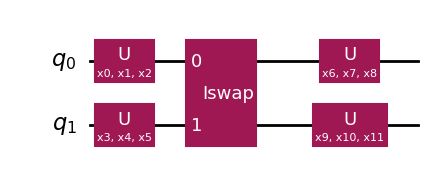

In [ ]:
ansatz = BasicCircuitAnsatz(
    iSwapGate(), 1, u_sequence=[(3, 3), (3, 3), (3, 3)], outside_layer_u=(3, 3)
)
# ansatz.generate_points(10_000)
# PulseConstraintPolytopes._plot_weyl_polytope_scatter(ansatz=ansatz)
print(ansatz._to_string("sqiS"))
ansatz.qc.draw("mpl")